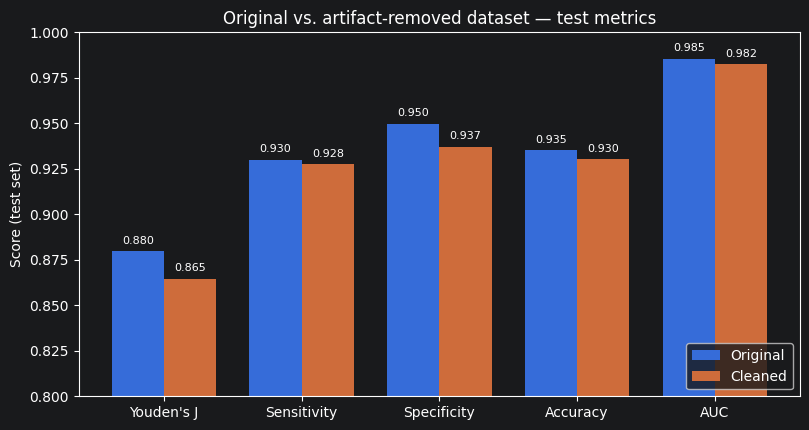

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
cleaned = {
    "sensitivity": 0.9276,
    "specificity": 0.9371,
    "accuracy": 0.9302,
    "auc": 0.9824,
}
cleaned["youden_j"] = cleaned["sensitivity"] + cleaned["specificity"] - 1.0

original = {
    "sensitivity": 0.9299,
    "specificity": 0.9497,
    "accuracy": 0.9353,
    "auc": 0.9854,
}
original["youden_j"] = original["sensitivity"] + original["specificity"] - 1.0

# Order of metrics
metrics = ["youden_j", "sensitivity", "specificity", "accuracy", "auc"]
labels = ["Youden's J", "Sensitivity", "Specificity", "Accuracy", "AUC"]

orig_vals = [original[m] for m in metrics]
clean_vals = [cleaned[m] for m in metrics]

# Plot
x = np.arange(len(metrics))
width = 0.38

fig, ax = plt.subplots(figsize=(8.2, 4.4))


bars1 = ax.bar(
    x - width/2,
    orig_vals,
    width,
    label="Original"
)

bars2 = ax.bar(
    x + width/2,
    clean_vals,
    width,
    label="Cleaned"
)

# Labels on top of bars
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.003,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_title("Original vs. artifact-removed dataset — test metrics")
ax.set_ylabel("Score (test set)")
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0.80, 1.00)

ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()